In [ ]:
from google.colab import files

uploaded = files.upload()


Saving scopus_2018-2020.csv to scopus_2018-2020 (1).csv


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving scopus_2021-2023.csv to scopus_2021-2023 (1).csv


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving scopus_2024-2026.csv to scopus_2024-2026 (1).csv


In [ ]:
import pandas as pd

# Load datasets
df1 = pd.read_csv("/content/scopus_2018-2020.csv")
df2 = pd.read_csv("/content/scopus_2021-2023.csv")
df3 = pd.read_csv("/content/scopus_2024-2026.csv")

# Merge
df = pd.concat([df1, df2, df3], ignore_index=True)

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns.tolist())

print("\n")

print("="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n")

print("="*60)
print("YEAR DISTRIBUTION")
print("="*60)

year_col = [c for c in df.columns if "year" in c.lower()][0]

print(
    df[year_col]
    .value_counts()
    .sort_index()
)

print("\n")

print("="*60)
print("FIRST 5 ROWS")
print("="*60)

display(df.head())

DATASET SHAPE
(6546, 9)


COLUMN NAMES
['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year', 'Cited by', 'Link', 'Abstract', 'Author Keywords']


MISSING VALUES
Authors               798
Author full names     798
Author(s) ID          798
Title                   0
Year                    0
Cited by              206
Link                    0
Abstract                0
Author Keywords      1429
dtype: int64


YEAR DISTRIBUTION
Year
2018     730
2019     718
2020     734
2021      68
2022     812
2023    1302
2024     511
2025    1214
2026     457
Name: count, dtype: int64


FIRST 5 ROWS


,Authors,Author full names,Author(s) ID,Title,Year,Cited by,Link,Abstract,Author Keywords
0,Berraies S.,"Berraies, Sarra (56332708600)",56332708600,Effect of middle managers’ cultural intelligen...,2020,52.0,https://www.scopus.com/pages/publications/8507...,Purpose: The purpose of this paper is to exami...,Collaborative climate; Cultural intelligence; ...
1,Adikaram A.S.; Kailasapathy P.,"Adikaram, Arosha S. (57190290033); Kailasapath...",57190290033; 55523613000,Handling Sexual Harassment Complaints in Sri L...,2020,3.0,https://www.scopus.com/pages/publications/8508...,Sexual harassment at the workplace continues t...,best practices; fairness; handling procedure; ...
2,Duxbury L.; Ormsbee F.,"Duxbury, Linda (6602744636); Ormsbee, Floyd (5...",6602744636; 57196374194,Does studying the past help us understand the ...,2020,10.0,https://www.scopus.com/pages/publications/8503...,Three demographic realities (large baby boom c...,employment relationship; generation; generatio...
3,NaN,NaN,NaN,Perceived servant leadership: the impact of se...,2020,0.0,https://www.scopus.com/pages/publications/8508...,Purpose: The purpose of this study is to asses...,Extrinsic job satisfaction; Intrinsic job sati...
4,NaN,NaN,NaN,Research shows oil and gas companies could do ...,2020,1.0,https://www.scopus.com/pages/publications/8508...,Purpose: The purpose of this study is to exami...,Co-working; Dual-careers; Expatriation; Gender...


In [ ]:
import pandas as pd

print("="*60)
print("YEAR COUNTS")
print("="*60)

print(df.groupby("Year").size())

print("\n")

print("="*60)
print("SAMPLE TITLES FROM 2021")
print("="*60)

sample_2021 = df[df["Year"] == 2021]["Title"].head(20)

for i, title in enumerate(sample_2021, 1):
    print(f"{i}. {title}")

print("\n")

print("="*60)
print("TOP 20 MOST FREQUENT KEYWORDS")
print("="*60)

keywords = (
    df["Author Keywords"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .str.lower()
)

print(keywords.value_counts().head(20))

YEAR COUNTS
Year
2018     730
2019     718
2020     734
2021      68
2022     812
2023    1302
2024     511
2025    1214
2026     457
dtype: int64


SAMPLE TITLES FROM 2021
1. The experience of commitment in the contemporary workplace: An exploratory reexamination of commitment model antecedents
2. Studying mutuality and perversity in the impacts of human resource management on societal well-being: Advancing a pluralist agenda
3. Refugee employment support: The HRM–CSR nexus and stakeholder co-dependency
4. Explaining different types of undeclared work: lessons from a 2019 Eurobarometer survey
5. COVID-19 and the uncertain future of HRM: Furlough, job retention and reform
6. The double-edged sword of job crafting: The effects of job crafting on changes in job demands and employee well-being
7. Labour Regulations, Growth and Employment: A South Asian Perspective
8. Abrasive leaders who changed: learning from their experience
9. Editorial
10. Non-Violence at Workplace: The Way to Happine

In [ ]:
human_terms = [
    "employee",
    "employees",
    "engagement",
    "wellbeing",
    "well-being",
    "leadership",
    "motivation",
    "satisfaction",
    "trust",
    "culture",
    "diversity",
    "inclusion",
    "team",
    "teams",
    "psychological",
    "talent",
    "learning",
    "training",
    "commitment",
    "empowerment",
    "resilience",
    "creativity",
    "collaboration",
    "performance",
    "career"
]

tech_terms = [
    "artificial intelligence",
    "ai",
    "machine learning",
    "algorithm",
    "algorithms",
    "automation",
    "automated",
    "digital",
    "analytics",
    "chatgpt",
    "generative ai",
    "big data",
    "robotics",
    "platform",
    "technology",
    "technologies",
    "data-driven",
    "information systems"
]

import re

df["combined_text"] = (
    df["Title"].fillna("") + " " +
    df["Abstract"].fillna("") + " " +
    df["Author Keywords"].fillna("")
).str.lower()

def count_terms(text, terms):
    count = 0
    for term in terms:
        count += len(re.findall(re.escape(term), text))
    return count

df["human_score"] = df["combined_text"].apply(
    lambda x: count_terms(x, human_terms)
)

df["tech_score"] = df["combined_text"].apply(
    lambda x: count_terms(x, tech_terms)
)

df["HCI"] = (
    df["human_score"] /
    (df["human_score"] + df["tech_score"] + 1)
)

print("="*60)
print("AVERAGE HCI BY YEAR")
print("="*60)

print(
    df.groupby("Year")["HCI"]
      .mean()
      .round(4)
)

AVERAGE HCI BY YEAR
Year
2018    0.5402
2019    0.5727
2020    0.5718
2021    0.5206
2022    0.5688
2023    0.4098
2024    0.5306
2025    0.5495
2026    0.5466
Name: HCI, dtype: float64


In [ ]:
from collections import Counter
import re

years_to_check = [2018, 2020, 2023, 2026]

stopwords = {
    "the","and","of","to","in","for","on","with",
    "a","an","is","are","by","at","from","that",
    "this","their","its","as","be","or","using",
    "study","research","paper","results","findings",
    "purpose","article","authors"
}

for year in years_to_check:

    text = " ".join(
        df[df["Year"] == year]["combined_text"]
        .astype(str)
        .tolist()
    )

    words = re.findall(r"\b[a-zA-Z-]+\b", text)

    words = [
        w.lower()
        for w in words
        if len(w) > 3 and w.lower() not in stopwords
    ]

    top_words = Counter(words).most_common(30)

    print("\n")
    print("="*70)
    print(f"TOP WORDS FOR {year}")
    print("="*70)

    for word, freq in top_words:
        print(f"{word:<25} {freq}")



TOP WORDS FOR 2018
work                      812
employees                 700
management                592
employee                  542
between                   541
performance               517
organizational            466
implications              466
human                     454
relationship              427
limited                   411
approach                  388
leadership                388
have                      363
design                    354
resource                  352
practices                 351
organizations             342
practical                 340
which                     329
role                      324
social                    319
value                     300
managers                  294
more                      291
these                     291
data                      278
were                      267
engagement                252
workplace                 245


TOP WORDS FOR 2020
work                      898
management                89

In [ ]:
traditional_hr = [
    "leadership",
    "engagement",
    "motivation",
    "satisfaction",
    "commitment",
    "culture",
    "wellbeing",
    "well-being",
    "retention",
    "training",
    "talent",
    "diversity",
    "inclusion"
]

In [ ]:
technology_hr = [
    "artificial intelligence",
    "ai",
    "machine learning",
    "analytics",
    "people analytics",
    "digital",
    "automation",
    "algorithm",
    "chatgpt",
    "generative ai",
    "big data",
    "robotics"
]

In [ ]:
strategic_hr = [
    "strategy",
    "strategic",
    "innovation",
    "transformation",
    "competitive advantage",
    "capability",
    "sustainability"
]

In [ ]:
import re
import pandas as pd

traditional_hr = [
    "leadership",
    "engagement",
    "motivation",
    "satisfaction",
    "commitment",
    "culture",
    "wellbeing",
    "well-being",
    "retention",
    "training",
    "talent",
    "diversity",
    "inclusion"
]

technology_hr = [
    "artificial intelligence",
    "ai",
    "machine learning",
    "analytics",
    "people analytics",
    "digital",
    "automation",
    "algorithm",
    "chatgpt",
    "generative ai",
    "big data",
    "robotics"
]

strategic_hr = [
    "strategy",
    "strategic",
    "innovation",
    "transformation",
    "competitive advantage",
    "capability",
    "sustainability"
]

def count_terms(text, term_list):
    text = str(text).lower()
    count = 0
    for term in term_list:
        count += len(re.findall(re.escape(term), text))
    return count

df["traditional_score"] = df["combined_text"].apply(
    lambda x: count_terms(x, traditional_hr)
)

df["technology_score"] = df["combined_text"].apply(
    lambda x: count_terms(x, technology_hr)
)

df["strategic_score"] = df["combined_text"].apply(
    lambda x: count_terms(x, strategic_hr)
)

yearly_scores = df.groupby("Year")[
    ["traditional_score",
     "technology_score",
     "strategic_score"]
].mean().round(3)

print(yearly_scores)

      traditional_score  technology_score  strategic_score
Year                                                      
2018              2.677             1.890            0.749
2019              2.887             2.221            0.719
2020              3.526             2.635            0.802
2021              2.971             2.162            0.544
2022              3.275             2.788            0.640
2023              2.211             2.620            0.518
2024              2.675             3.072            0.777
2025              3.619             3.935            0.962
2026              3.184             3.856            0.954


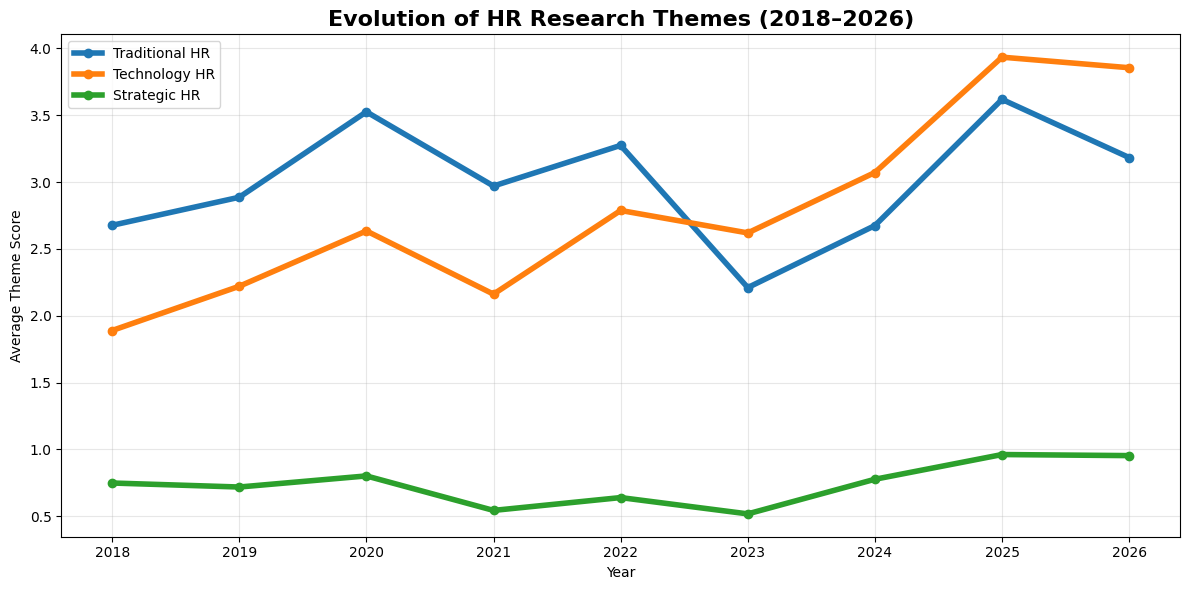

In [ ]:
import matplotlib.pyplot as plt

yearly_scores.plot(
    figsize=(12,6),
    linewidth=4,
    marker='o'
)

plt.title(
    "Evolution of HR Research Themes (2018–2026)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year")
plt.ylabel("Average Theme Score")

plt.grid(True, alpha=0.3)

plt.legend(
    ["Traditional HR",
     "Technology HR",
     "Strategic HR"]
)

plt.tight_layout()

plt.show()

In [ ]:
pre = df[df["Year"] <= 2021]
post = df[df["Year"] >= 2023]

print("PRE-AI ERA")
print(pre[[
    "traditional_score",
    "technology_score",
    "strategic_score"
]].mean())

print("\n")

print("POST-AI ERA")
print(post[[
    "traditional_score",
    "technology_score",
    "strategic_score"
]].mean())

PRE-AI ERA
traditional_score    3.029778
technology_score     2.247111
strategic_score      0.750667
dtype: float64


POST-AI ERA
traditional_score    2.897245
technology_score     3.306544
strategic_score      0.767796
dtype: float64


Significance Testing


In [ ]:
from scipy.stats import mannwhitneyu

pre = df[df["Year"] <= 2021]
post = df[df["Year"] >= 2023]

variables = [
    "traditional_score",
    "technology_score",
    "strategic_score"
]

print("="*70)
print("MANN-WHITNEY U TEST RESULTS")
print("="*70)

for var in variables:

    stat, p = mannwhitneyu(
        pre[var],
        post[var],
        alternative="two-sided"
    )

    print(f"\n{var}")
    print(f"U Statistic = {stat:.2f}")
    print(f"P Value     = {p:.10f}")

MANN-WHITNEY U TEST RESULTS

traditional_score
U Statistic = 3942794.50
P Value     = 0.6907411837

technology_score
U Statistic = 3345921.50
P Value     = 0.0000000000

strategic_score
U Statistic = 3888581.00
P Value     = 0.5144516960


Technology Dominance Ratio


In [ ]:
ratio = yearly_scores.copy()

ratio["tech_traditional_ratio"] = (
    ratio["technology_score"] /
    ratio["traditional_score"]
)

print(ratio["tech_traditional_ratio"])

Year
2018    0.706014
2019    0.769311
2020    0.747306
2021    0.727701
2022    0.851298
2023    1.184984
2024    1.148411
2025    1.087317
2026    1.211055
Name: tech_traditional_ratio, dtype: float64


Find The Drivers


In [ ]:
tech_terms = [
    "artificial intelligence",
    "ai",
    "machine learning",
    "analytics",
    "people analytics",
    "digital",
    "automation",
    "algorithm",
    "chatgpt",
    "generative ai",
    "big data",
    "robotics"
]

for term in tech_terms:

    yearly = (
        df.groupby("Year")["combined_text"]
        .apply(lambda x:
               sum(str(text).lower().count(term)
                   for text in x))
    )

    print("\n")
    print("="*60)
    print(term.upper())
    print("="*60)
    print(yearly)



ARTIFICIAL INTELLIGENCE
Year
2018      2
2019      2
2020     12
2021      1
2022     55
2023    163
2024     30
2025    176
2026     64
Name: combined_text, dtype: int64


AI
Year
2018    1286
2019    1566
2020    1802
2021     137
2022    1949
2023    2845
2024    1229
2025    3851
2026    1280
Name: combined_text, dtype: int64


MACHINE LEARNING
Year
2018     1
2019     0
2020     8
2021     1
2022    11
2023    30
2024     7
2025    49
2026    14
Name: combined_text, dtype: int64


ANALYTICS
Year
2018     47
2019     18
2020     17
2021      1
2022     56
2023     83
2024     65
2025    132
2026     37
Name: combined_text, dtype: int64


PEOPLE ANALYTICS
Year
2018     4
2019     0
2020     0
2021     0
2022    11
2023    11
2024    14
2025    14
2026    10
Name: combined_text, dtype: int64


DIGITAL
Year
2018     24
2019      9
2020     76
2021      7
2022    124
2023    165
2024    148
2025    308
2026    214
Name: combined_text, dtype: int64


AUTOMATION
Year
2018    12
2019   

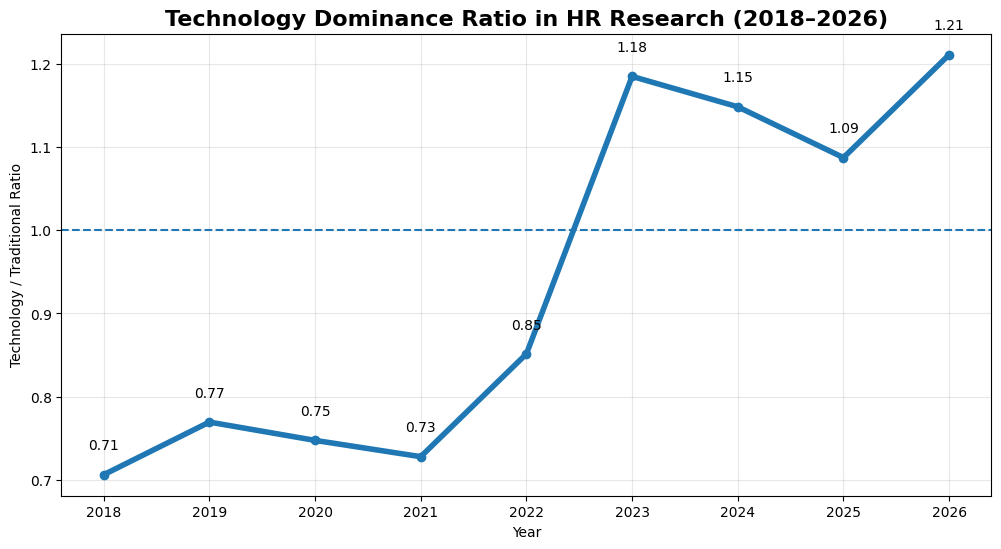

In [ ]:
import matplotlib.pyplot as plt

ratio = yearly_scores.copy()

ratio["tech_traditional_ratio"] = (
    ratio["technology_score"] /
    ratio["traditional_score"]
)

plt.figure(figsize=(12,6))

plt.plot(
    ratio.index,
    ratio["tech_traditional_ratio"],
    linewidth=4,
    marker="o"
)

plt.axhline(
    y=1,
    linestyle="--"
)

plt.title(
    "Technology Dominance Ratio in HR Research (2018–2026)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Technology / Traditional Ratio")

plt.grid(alpha=0.3)

for x, y in zip(
    ratio.index,
    ratio["tech_traditional_ratio"]
):
    plt.text(
        x,
        y+0.03,
        f"{y:.2f}",
        ha="center"
    )

plt.show()

Build the Driver Table


In [ ]:
drivers = [
    "artificial intelligence",
    "machine learning",
    "analytics",
    "digital",
    "algorithm",
    "automation"
]

for term in drivers:

    pre_count = 0
    post_count = 0

    for text in pre["combined_text"]:
        pre_count += str(text).lower().count(term)

    for text in post["combined_text"]:
        post_count += str(text).lower().count(term)

    growth = ((post_count - pre_count) / max(pre_count,1)) * 100

    print(f"{term:<25}")
    print(f"Pre-AI  : {pre_count}")
    print(f"Post-AI : {post_count}")
    print(f"Growth% : {growth:.2f}")
    print("-"*50)

artificial intelligence  
Pre-AI  : 17
Post-AI : 433
Growth% : 2447.06
--------------------------------------------------
machine learning         
Pre-AI  : 10
Post-AI : 100
Growth% : 900.00
--------------------------------------------------
analytics                
Pre-AI  : 83
Post-AI : 317
Growth% : 281.93
--------------------------------------------------
digital                  
Pre-AI  : 116
Post-AI : 835
Growth% : 619.83
--------------------------------------------------
algorithm                
Pre-AI  : 6
Post-AI : 398
Growth% : 6533.33
--------------------------------------------------
automation               
Pre-AI  : 17
Post-AI : 82
Growth% : 382.35
--------------------------------------------------


In [ ]:
pre_papers = len(pre)
post_papers = len(post)

print("Pre papers:", pre_papers)
print("Post papers:", post_papers)

Pre papers: 2250
Post papers: 3484


Normalize Everything

In [ ]:
drivers = [
    "artificial intelligence",
    "machine learning",
    "analytics",
    "digital",
    "algorithm",
    "automation"
]

results = []

for term in drivers:

    pre_count = sum(
        str(text).lower().count(term)
        for text in pre["combined_text"]
    )

    post_count = sum(
        str(text).lower().count(term)
        for text in post["combined_text"]
    )

    pre_rate = (pre_count / len(pre)) * 100
    post_rate = (post_count / len(post)) * 100

    growth = ((post_rate - pre_rate) / max(pre_rate, 0.0001)) * 100

    results.append([
        term,
        round(pre_rate,2),
        round(post_rate,2),
        round(growth,2)
    ])

import pandas as pd

driver_table = pd.DataFrame(
    results,
    columns=[
        "Concept",
        "Pre_Per_100_Papers",
        "Post_Per_100_Papers",
        "Growth_%"
    ]
)

print(driver_table)

                   Concept  Pre_Per_100_Papers  Post_Per_100_Papers  Growth_%
0  artificial intelligence                0.76                12.43   1544.91
1         machine learning                0.44                 2.87    545.81
2                analytics                3.69                 9.10    146.65
3                  digital                5.16                23.97    364.87
4                algorithm                0.27                11.42   4183.87
5               automation                0.76                 2.35    211.51


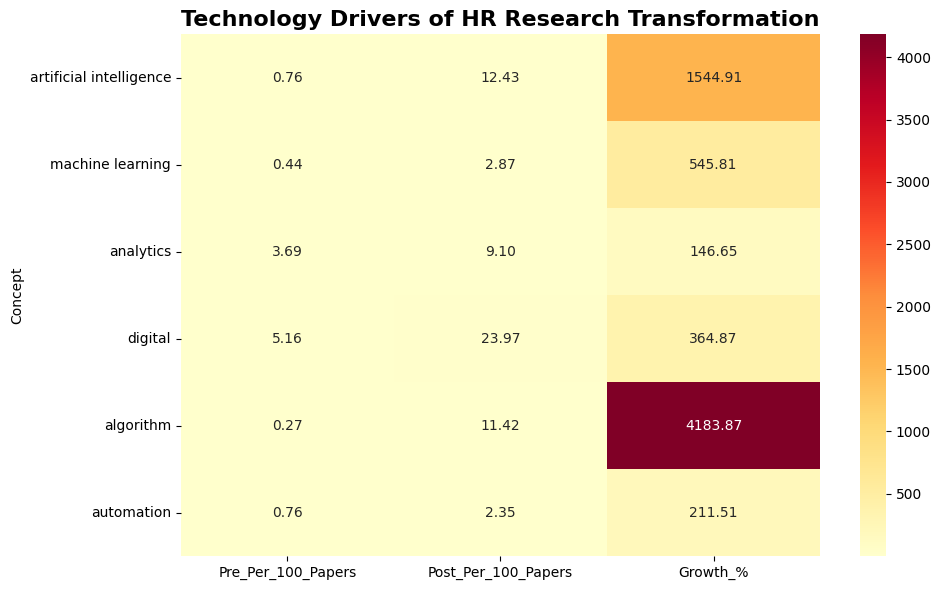

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = driver_table.set_index("Concept")

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title(
    "Technology Drivers of HR Research Transformation",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
df["ATI"] = (
    df["technology_score"] /
    (df["traditional_score"] +
     df["strategic_score"] + 1)
)

ati_yearly = (
    df.groupby("Year")["ATI"]
      .mean()
      .round(3)
)

print(ati_yearly)

Year
2018    0.848
2019    0.959
2020    0.995
2021    0.840
2022    1.191
2023    1.297
2024    1.244
2025    1.414
2026    1.396
Name: ATI, dtype: float64


ATI Significance Test


In [ ]:
pre_ati = df[df["Year"] <= 2021]["ATI"]
post_ati = df[df["Year"] >= 2023]["ATI"]

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    pre_ati,
    post_ati,
    alternative="two-sided"
)

print("ATI U Statistic:", stat)
print("ATI p-value:", p)

ATI U Statistic: 3337095.0
ATI p-value: 9.040385915682768e-22


ATI Figure (Figure 2)

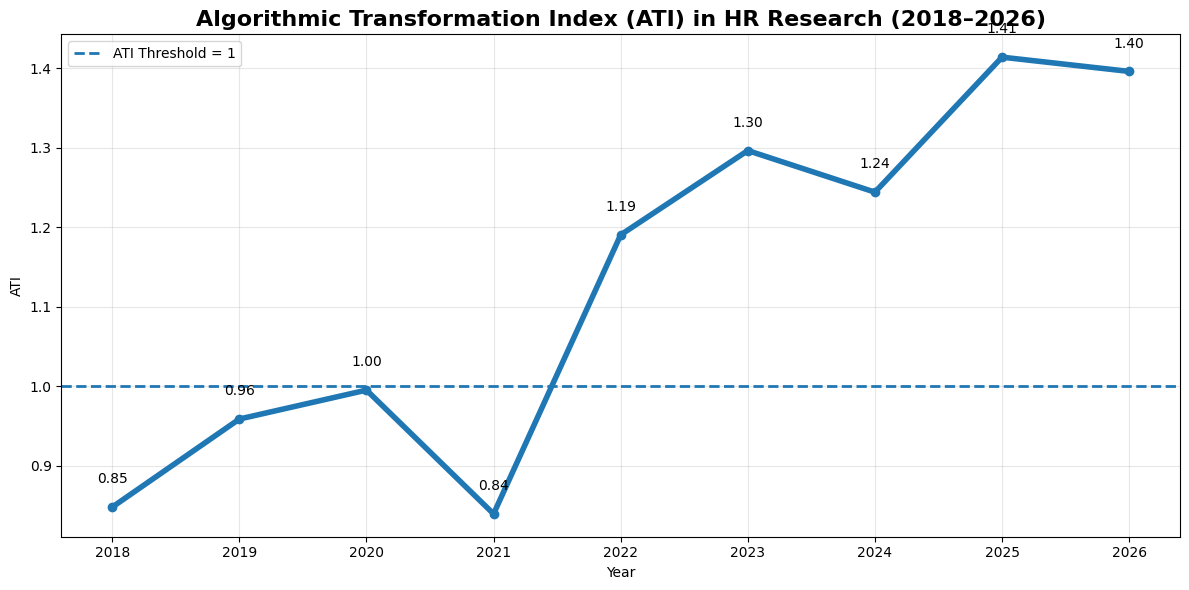

In [ ]:
import matplotlib.pyplot as plt

ati_yearly = (
    df.groupby("Year")["ATI"]
      .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    ati_yearly.index,
    ati_yearly.values,
    marker="o",
    linewidth=4
)

plt.axhline(
    y=1,
    linestyle="--",
    linewidth=2,
    label="ATI Threshold = 1"
)

plt.title(
    "Algorithmic Transformation Index (ATI) in HR Research (2018–2026)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("ATI")

plt.legend()

plt.grid(alpha=0.3)

for x,y in zip(
    ati_yearly.index,
    ati_yearly.values
):
    plt.text(
        x,
        y+0.03,
        f"{y:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Effect Size

In [ ]:
import numpy as np

pre_ati = df[df["Year"] <= 2021]["ATI"]
post_ati = df[df["Year"] >= 2023]["ATI"]

mean_diff = post_ati.mean() - pre_ati.mean()

pooled_std = np.sqrt(
    (
        ((len(pre_ati)-1)*(pre_ati.std()**2))
        +
        ((len(post_ati)-1)*(post_ati.std()**2))
    )
    /
    (len(pre_ati)+len(post_ati)-2)
)

cohens_d = mean_diff / pooled_std

print("Mean Difference:", round(mean_diff,4))
print("Cohen's d:", round(cohens_d,4))

Mean Difference: 0.4115
Cohen's d: 0.2114


Keyword Evolution Heatmap

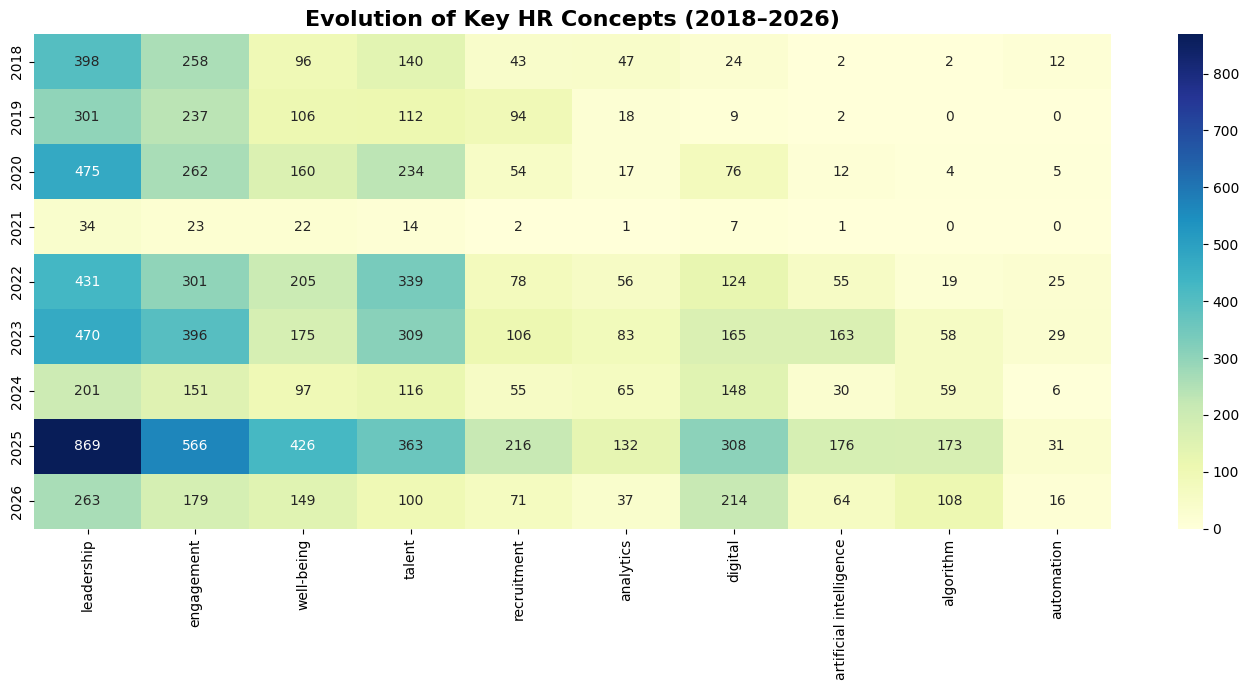

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

keywords_to_track = [
    "leadership",
    "engagement",
    "well-being",
    "talent",
    "recruitment",
    "analytics",
    "digital",
    "artificial intelligence",
    "algorithm",
    "automation"
]

heatmap_data = []

for year in sorted(df["Year"].unique()):

    texts = " ".join(
        df[df["Year"] == year]["combined_text"]
        .astype(str)
    ).lower()

    row = []

    for kw in keywords_to_track:
        row.append(texts.count(kw))

    heatmap_data.append(row)

heatmap_df = pd.DataFrame(
    heatmap_data,
    index=sorted(df["Year"].unique()),
    columns=keywords_to_track
)

plt.figure(figsize=(14,7))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title(
    "Evolution of Key HR Concepts (2018–2026)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

ATI Robustness Check

In [ ]:
reduced_tech_terms = [
    "analytics",
    "digital",
    "automation"
]

def count_terms(text, terms):
    import re
    count = 0

    for term in terms:
        count += len(
            re.findall(
                re.escape(term),
                str(text).lower()
            )
        )

    return count

df["reduced_tech_score"] = (
    df["combined_text"]
    .apply(
        lambda x:
        count_terms(
            x,
            reduced_tech_terms
        )
    )
)

df["ATI_robust"] = (
    df["reduced_tech_score"]
    /
    (
        df["traditional_score"]
        +
        df["strategic_score"]
        + 1
    )
)

print(
    df.groupby("Year")["ATI_robust"]
      .mean()
)

Year
2018    0.065152
2019    0.015738
2020    0.040923
2021    0.041176
2022    0.099253
2023    0.104410
2024    0.139011
2025    0.109632
2026    0.200062
Name: ATI_robust, dtype: float64


Paper-Ready Results Table

In [ ]:
print(df.columns.tolist())

['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year', 'Cited by', 'Link', 'Abstract', 'Author Keywords', 'combined_text', 'human_score', 'tech_score', 'HCI', 'traditional_score', 'technology_score', 'strategic_score', 'ATI', 'reduced_tech_score', 'ATI_robust']


In [ ]:
pre = df[df["Year"] <= 2021].copy()
post = df[df["Year"] >= 2023].copy()

print("Pre:", pre.shape)
print("Post:", post.shape)

print("\nATI Exists?")
print("ATI" in pre.columns)
print("ATI" in post.columns)

Pre: (2250, 19)
Post: (3484, 19)

ATI Exists?
True
True


In [ ]:
import numpy as np

pre_ati = pre["ATI"]
post_ati = post["ATI"]

mean_diff = post_ati.mean() - pre_ati.mean()

pooled_std = np.sqrt(
    (
        ((len(pre_ati)-1)*(pre_ati.std()**2))
        +
        ((len(post_ati)-1)*(post_ati.std()**2))
    )
    /
    (len(pre_ati)+len(post_ati)-2)
)

cohens_d = mean_diff / pooled_std

print("Mean Difference:", round(mean_diff,4))
print("Cohen's d:", round(cohens_d,4))

Mean Difference: 0.4115
Cohen's d: 0.2114


In [ ]:
import numpy as np

pre_ati = pre["ATI"]
post_ati = post["ATI"]

mean_diff = post_ati.mean() - pre_ati.mean()

pooled_std = np.sqrt(
    (
        ((len(pre_ati)-1)*(pre_ati.std()**2))
        +
        ((len(post_ati)-1)*(post_ati.std()**2))
    )
    /
    (len(pre_ati)+len(post_ati)-2)
)

cohens_d = mean_diff / pooled_std

print("Mean Difference:", round(mean_diff,4))
print("Cohen's d:", round(cohens_d,4))

Mean Difference: 0.4115
Cohen's d: 0.2114


In [ ]:
print(
    df.groupby("Year")["ATI_robust"]
      .mean()
      .round(3)
)

Year
2018    0.065
2019    0.016
2020    0.041
2021    0.041
2022    0.099
2023    0.104
2024    0.139
2025    0.110
2026    0.200
Name: ATI_robust, dtype: float64


In [ ]:
results_table = pd.DataFrame({
    "Metric":[
        "Traditional HR",
        "Technology HR",
        "Strategic HR",
        "ATI"
    ],
    "Pre_AI":[
        pre["traditional_score"].mean(),
        pre["technology_score"].mean(),
        pre["strategic_score"].mean(),
        pre["ATI"].mean()
    ],
    "Post_AI":[
        post["traditional_score"].mean(),
        post["technology_score"].mean(),
        post["strategic_score"].mean(),
        post["ATI"].mean()
    ]
})

results_table["Percent_Change"] = (
    (
        results_table["Post_AI"]
        -
        results_table["Pre_AI"]
    )
    /
    results_table["Pre_AI"]
) * 100

print(results_table.round(3))

           Metric  Pre_AI  Post_AI  Percent_Change
0  Traditional HR   3.030    2.897          -4.374
1   Technology HR   2.247    3.307          47.146
2    Strategic HR   0.751    0.768           2.282
3             ATI   0.931    1.343          44.187
